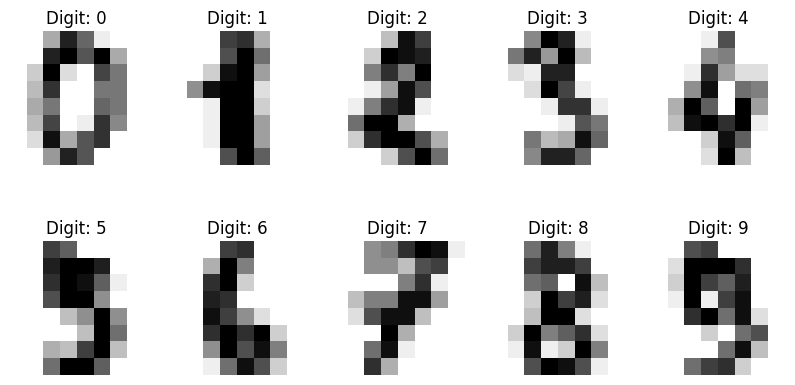

In [7]:
# Code source: Gaël Varoquaux
# Modified for documentation by Jaques Grobler
# License: BSD 3 clause
# Adaptado de:
# https://qu4nt.github.io/sklearn-doc-es/auto_examples/datasets/plot_digits_last_image.html

from sklearn import datasets
import matplotlib.pyplot as plt

# Load the digits dataset
digits = datasets.load_digits()

# Display all digits
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(digits.images[i], cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title(f'Digit: {digits.target[i]}')
    plt.axis('off')

plt.show()

Características del número 1:
[[ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  1.  0.]
 [ 0.  0.  0. ... 15.  4.  0.]
 ...
 [ 0.  0.  1. ... 10.  0.  0.]
 [ 0.  0.  8. ...  7.  0.  0.]
 [ 0.  0.  6. ...  4.  0.  0.]]

Target del número 1:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


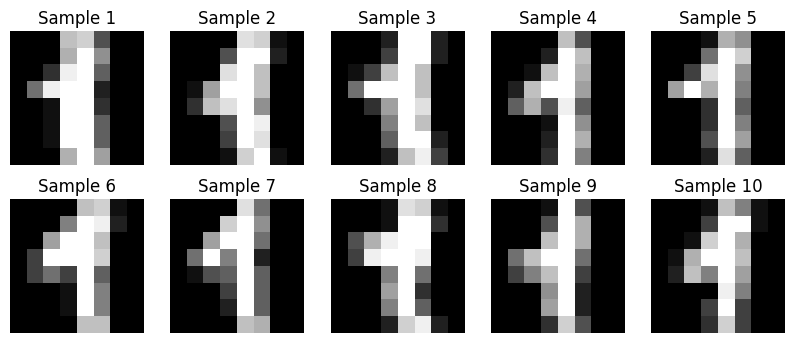

In [8]:
import matplotlib.pyplot as plt

# Cargar el conjunto de datos de dígitos
digits = datasets.load_digits()

# Obtener las características y el target del número 0
X_zero = digits.data[digits.target == 1]
y_zero = digits.target[digits.target == 1]

# Mostrar las características del número 0
print("Características del número 1:")
print(X_zero)

# Mostrar el target del número 0
print("\nTarget del número 1:")
print(y_zero)

# Mostrar las imágenes del número 0
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_zero[i].reshape(8, 8), cmap='gray')
    plt.title(f"Sample {i + 1}")
    plt.axis('off')
plt.show()

In [9]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

#Mostrar pesos cada n epocas
n_epocas = 10

# Cargar el conjunto de datos de dígitos
digits = load_digits()

# Preprocesamiento de los datos
X, y = digits.data, digits.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Mostrar los valores de X (características)
print("Valores de X (características):")
print(digits.data)

# Mostrar los valores de y (etiquetas)
print("\nValores de y (etiquetas):")
print(digits.target)

Valores de X (características):
[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]

Valores de y (etiquetas):
[0 1 2 ... 8 9 8]


Época    0/500 - Precisión: 0.0752 - Pérdida: 0.3010
Época   50/500 - Precisión: 0.1072 - Pérdida: 0.1000
Época  100/500 - Precisión: 0.1072 - Pérdida: 0.1000
Época  150/500 - Precisión: 0.1072 - Pérdida: 0.1000
Época  200/500 - Precisión: 0.1072 - Pérdida: 0.1000
Época  250/500 - Precisión: 0.1072 - Pérdida: 0.1000
Época  300/500 - Precisión: 0.1072 - Pérdida: 0.1000
Época  350/500 - Precisión: 0.1072 - Pérdida: 0.1000
Época  400/500 - Precisión: 0.1072 - Pérdida: 0.1000
Época  450/500 - Precisión: 0.1072 - Pérdida: 0.1000
Época  500/500 - Precisión: 0.1072 - Pérdida: 0.1000

Precisión en el conjunto de prueba: 0.0778


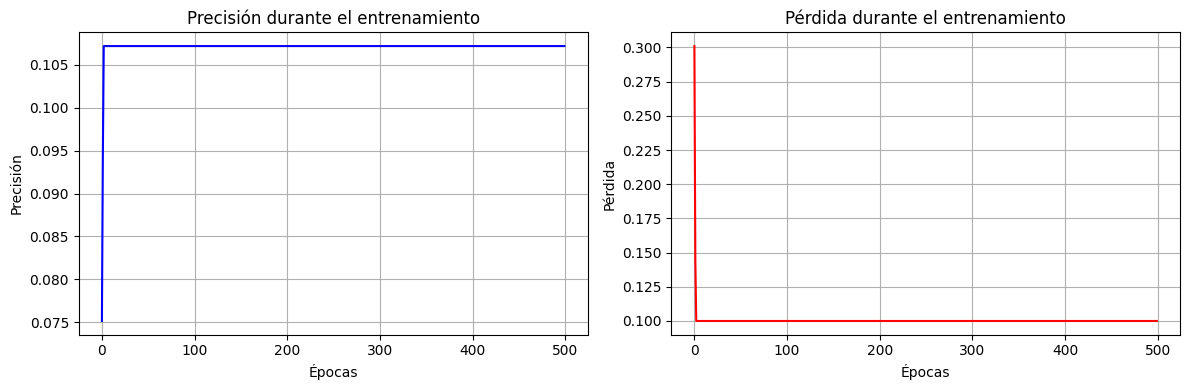

In [10]:

# Dividir el conjunto de datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# One-hot encoding para las etiquetas (NECESARIO para clasificación multi-clase con sigmoid)
def one_hot(y, num_classes=10):
    oh = np.zeros((len(y), num_classes))
    oh[np.arange(len(y)), y] = 1
    return oh

y_train_oh = one_hot(y_train)

# Función de activación
def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

# Derivada de la función de activación
def sigmoid_derivative(x):
    return x * (1 - x)

# Inicialización de los pesos y el sesgo
input_neurons = X_train.shape[1]
hidden_neurons = 64
output_neurons = 10
learning_rate = 0.1
epochs = 500

n_epocas = 50 # Mostrar progreso cada n épocas

# Inicialización aleatoria de los pesos
np.random.seed(42)
weights_input_hidden = np.random.uniform(-0.5, 0.5, size=(input_neurons, hidden_neurons))
weights_hidden_output = np.random.uniform(-0.5, 0.5, size=(hidden_neurons, output_neurons))

# Listas para almacenar la precisión y la función de pérdida durante el entrenamiento
accuracy_list = []
loss_list = []

# Entrenamiento de la red neuronal utilizando backpropagation
for epoch in range(epochs):
    # Forward propagation
    hidden_input = np.dot(X_train, weights_input_hidden)
    hidden_output = sigmoid(hidden_input)
    output_input = np.dot(hidden_output, weights_hidden_output)
    output = sigmoid(output_input)

    # Calcular la precisión y la pérdida en cada época
    accuracy = accuracy_score(y_train, np.argmax(output, axis=1))
    loss = np.mean(np.square(y_train_oh - output))

    accuracy_list.append(accuracy)
    loss_list.append(loss)

    # Backpropagation (usando one-hot targets)
    output_error = y_train_oh - output
    output_delta = output_error * sigmoid_derivative(output)

    hidden_error = output_delta.dot(weights_hidden_output.T)
    hidden_delta = hidden_error * sigmoid_derivative(hidden_output)

    # Actualización de los pesos
    weights_hidden_output += hidden_output.T.dot(output_delta) * learning_rate
    weights_input_hidden += X_train.T.dot(hidden_delta) * learning_rate

    # Mostrar progreso cada n épocas
    if epoch % n_epocas == 0:
        print(f'Época {epoch:4d}/{epochs} - Precisión: {accuracy:.4f} - Pérdida: {loss:.4f}')

print(f'Época {epochs:4d}/{epochs} - Precisión: {accuracy_list[-1]:.4f} - Pérdida: {loss_list[-1]:.4f}')

# Predicción en el conjunto de prueba
hidden_output = sigmoid(np.dot(X_test, weights_input_hidden))
predicted_output = sigmoid(np.dot(hidden_output, weights_hidden_output))
predicted_labels = np.argmax(predicted_output, axis=1)

# Calcular la precisión en el conjunto de prueba
accuracy_test = accuracy_score(y_test, predicted_labels)
print(f"\nPrecisión en el conjunto de prueba: {accuracy_test:.4f}")

# Visualizar la precisión y la función de pérdida durante el entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(epochs), accuracy_list, color='b')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(epochs), loss_list, color='r')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.grid(True)

plt.tight_layout()
plt.show()


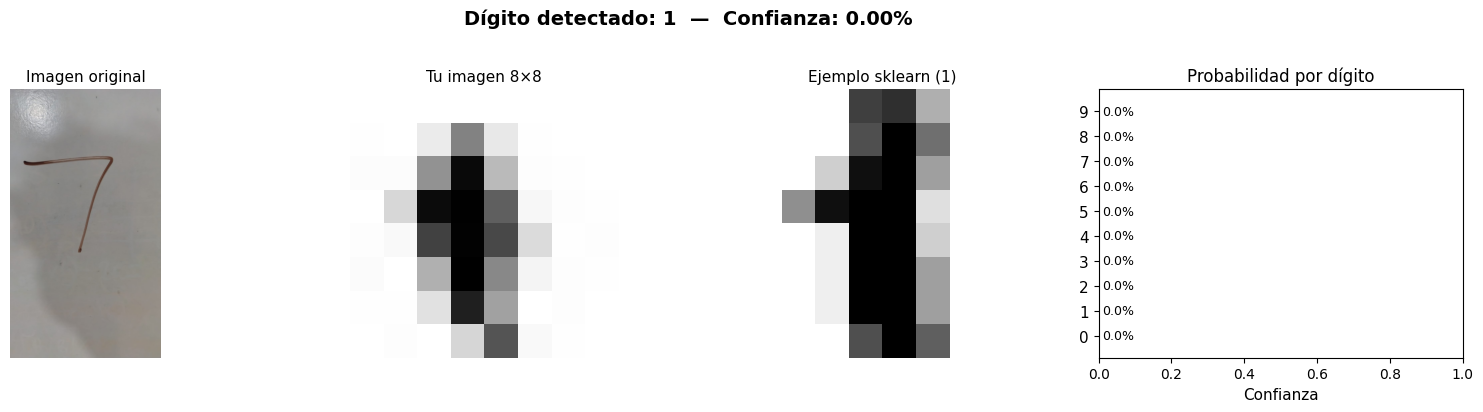

📷 Archivo: seven.jpeg
🔢 Dígito predicho: 1
📊 Confianza: 0.00%
🏆 Top 3: 1(0.0%), 0(0.0%), 5(0.0%)
--------------------------------------------------


In [20]:

import numpy as np
from PIL import Image, ImageFilter, ImageOps
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog

# ==================== FUNCIONES DE PREDICCIÓN ====================

def preprocesar_imagen(ruta_imagen):
    """Carga una foto real y la convierte al formato 8x8 compatible con sklearn digits."""
    img_original = Image.open(ruta_imagen)
    img = Image.open(ruta_imagen).convert('L')

    # 1. Invertir si el fondo es claro (hoja blanca → fondo oscuro como sklearn)
    img_array = np.array(img, dtype=np.float64)
    if np.mean(img_array) > 127:
        img = ImageOps.invert(img)

    # 2. Aplicar filtro gaussiano para suavizar ruido
    img = img.filter(ImageFilter.GaussianBlur(radius=2))

    # 3. Binarizar con umbral adaptativo (Otsu-like)
    img_array = np.array(img, dtype=np.float64)
    threshold = np.mean(img_array) + 0.5 * np.std(img_array)
    img_array[img_array < threshold] = 0
    img_array[img_array >= threshold] = 255

    # 4. Recortar al bounding box del dígito (quitar bordes vacíos)
    coords = np.argwhere(img_array > 0)
    if len(coords) > 0:
        y0, x0 = coords.min(axis=0)
        y1, x1 = coords.max(axis=0)
        # Agregar un pequeño margen
        margin = max(2, int(0.1 * max(y1 - y0, x1 - x0)))
        y0 = max(0, y0 - margin)
        x0 = max(0, x0 - margin)
        y1 = min(img_array.shape[0], y1 + margin)
        x1 = min(img_array.shape[1], x1 + margin)
        img_array = img_array[y0:y1, x0:x1]

    # 5. Hacer cuadrada la imagen (con padding)
    h, w = img_array.shape
    if h > w:
        pad = (h - w) // 2
        img_array = np.pad(img_array, ((0, 0), (pad, h - w - pad)), mode='constant')
    elif w > h:
        pad = (w - h) // 2
        img_array = np.pad(img_array, ((pad, w - h - pad), (0, 0)), mode='constant')

    # 6. Redimensionar a 8x8 con antialiasing
    img_pil = Image.fromarray(img_array.astype(np.uint8))
    img_resized = img_pil.resize((8, 8), Image.LANCZOS)
    img_8x8 = np.array(img_resized, dtype=np.float64)

    # 7. Normalizar al rango 0-16 (como sklearn digits)
    if img_8x8.max() > 0:
        img_8x8 = (img_8x8 / img_8x8.max()) * 16

    return img_8x8, img_original


def predecir_digito(img_8x8):
    """Predice el dígito usando los pesos entrenados en las celdas anteriores."""
    img_flat = img_8x8.flatten().reshape(1, -1)
    img_scaled = (img_flat - scaler.mean_) / scaler.scale_

    hidden = sigmoid(np.dot(img_scaled, weights_input_hidden))
    output = sigmoid(np.dot(hidden, weights_hidden_output))
    return output[0]


def mostrar_resultado(img_original, img_8x8, probabilidades, nombre_archivo=""):
    """Muestra la imagen original, la versión 8x8, un ejemplo de sklearn y las probabilidades."""
    digito = np.argmax(probabilidades)
    confianza = probabilidades[digito]

    # Buscar un ejemplo del mismo dígito en sklearn para comparar
    ejemplo_idx = np.where(digits.target == digito)[0][0]
    ejemplo_sklearn = digits.images[ejemplo_idx]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(img_original, cmap='gray')
    axes[0].set_title("Imagen original", fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(img_8x8, cmap=plt.cm.gray_r, interpolation='nearest')
    axes[1].set_title(f"Tu imagen 8×8", fontsize=11)
    axes[1].axis('off')

    axes[2].imshow(ejemplo_sklearn, cmap=plt.cm.gray_r, interpolation='nearest')
    axes[2].set_title(f"Ejemplo sklearn ({digito})", fontsize=11)
    axes[2].axis('off')

    colores = ['#888888'] * 10
    colores[digito] = '#2ecc71'
    axes[3].barh(range(10), probabilidades, color=colores, edgecolor='white')
    axes[3].set_yticks(range(10))
    axes[3].set_yticklabels([str(i) for i in range(10)], fontsize=11)
    axes[3].set_xlabel('Confianza', fontsize=11)
    axes[3].set_title('Probabilidad por dígito', fontsize=12)
    axes[3].set_xlim(0, 1)
    for i, p in enumerate(probabilidades):
        axes[3].text(p + 0.01, i, f'{p:.1%}', va='center', fontsize=9)

    plt.suptitle(f'Dígito detectado: {digito}  —  Confianza: {confianza:.2%}',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"📷 Archivo: {nombre_archivo}")
    print(f"🔢 Dígito predicho: {digito}")
    print(f"📊 Confianza: {confianza:.2%}")
    # Mostrar top 3 predicciones
    top3 = np.argsort(probabilidades)[::-1][:3]
    print(f"🏆 Top 3: {', '.join(f'{d}({probabilidades[d]:.1%})' for d in top3)}")


# ==================== SELECCIONAR IMAGEN(ES) CON DIÁLOGO ====================

root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)

rutas = filedialog.askopenfilenames(
    title="Selecciona una o más imágenes de dígitos",
    filetypes=[
        ("Imágenes", "*.png *.jpg *.jpeg *.bmp *.gif *.webp"),
        ("Todos los archivos", "*.*"),
    ],
)
root.destroy()

if rutas:
    for ruta in rutas:
        nombre = ruta.split("/")[-1].split("\\")[-1]
        img_8x8, img_original = preprocesar_imagen(ruta)
        probabilidades = predecir_digito(img_8x8)
        mostrar_resultado(img_original, img_8x8, probabilidades, nombre)
        print("-" * 50)
else:
    print("No se seleccionó ninguna imagen.")
